In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from PIL import Image
from io import BytesIO

<h1>Q1</h1>

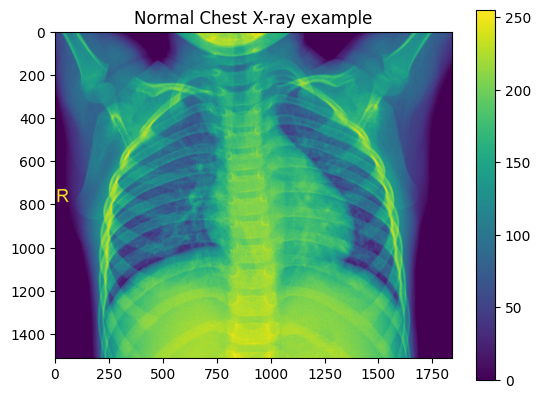

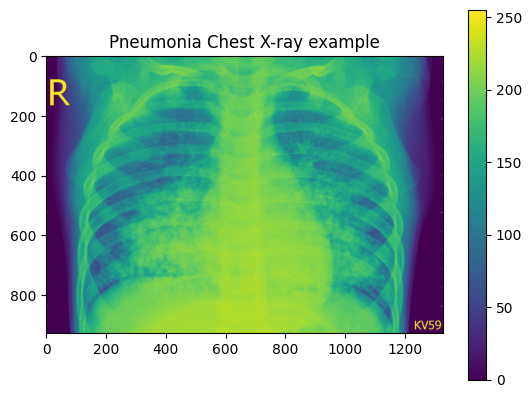

In [23]:
# Load the data
train_url = 'ml4h_data/p2/part2/archive/chest_xray/train'
test_url = 'ml4h_data/p2/part2/archive/chest_xray/test'
val_url = 'ml4h_data/p2/part2/archive/chest_xray/val'

normal_url = '/NORMAL'
pneumonia_url = '/PNEUMONIA'

# Plot an example image
img_url = os.listdir(train_url + normal_url)[0]
img = Image.open(train_url + normal_url + '/' + img_url)
plt.imshow(img)
plt.title('Normal Chest X-ray example')
plt.colorbar()
plt.show()

img_url = os.listdir(train_url + pneumonia_url)[0]
img = Image.open(train_url + pneumonia_url + '/' + img_url)
plt.imshow(img)
plt.title('Pneumonia Chest X-ray example')
plt.colorbar()
plt.show()

<h2>Q1.2</h2>

The visual differences are quite noticeable between normal and disease samples, as the disease samples exhibit much higher average pixel intensity in the region of the lungs. This is caused by inflammation appearing in the x rays.

<h2>Q1.3</h2>
One source of bias that could influence the model is the uneven distribution of pneumonia and normal x rays. As we can see, half of the images are bacterial pneumonia and the other half is somewhat evenly distributed between normal and viral.

Normal: 1341, Pneumonia_Bacterial: 2530, Pneumonia_Viral: 1345


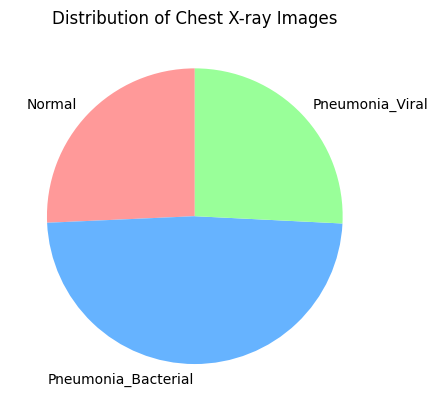

In [24]:
base_url = train_url

normal_count = len(os.listdir(base_url + normal_url))

pneumonia_files = os.listdir(base_url + pneumonia_url)
pneumonia_bacterial_count = len([f for f in pneumonia_files if 'bacteria' in f])
pneumonia_viral_count = len([f for f in pneumonia_files if 'virus' in f])

categories = ['Normal', 'Pneumonia_Bacterial', 'Pneumonia_Viral']
sizes = [normal_count, pneumonia_bacterial_count, pneumonia_viral_count]
colors = ['#FF9999', '#66B3FF', '#99FF99']

print(f"Normal: {normal_count}, Pneumonia_Bacterial: {pneumonia_bacterial_count}, Pneumonia_Viral: {pneumonia_viral_count}")

plt.pie([normal_count, pneumonia_bacterial_count, pneumonia_viral_count], labels=categories, colors=colors, startangle=90)

plt.title('Distribution of Chest X-ray Images')
plt.show()

<h2>Q1.4</h2>
For further analysis, we preprocess the images by making sure they are the same dimensions (224x224). We first downsample the images if they are too large and we add padding to make sure that the aspect ratio is maintained.

In [25]:
import cv2

(1511, 1840)


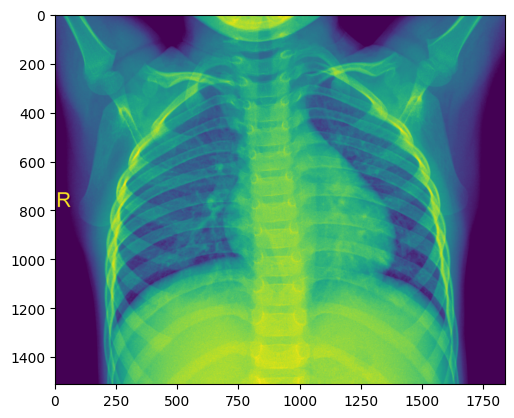

In [26]:
img_url = os.listdir(train_url + normal_url)[0]
img = cv2.imread(train_url + normal_url + '/' + img_url, cv2.IMREAD_GRAYSCALE)
print(img.shape)
plt.imshow(img)

df = pd.DataFrame(columns=['url', 'label', 'width', 'height'])
test_df = pd.DataFrame(columns=['url', 'label', 'width', 'height'])

for f in os.listdir(train_url + normal_url):
    img = cv2.imread(train_url + normal_url + '/' + f)
    url = train_url + normal_url + '/' + f
    df = pd.concat([df, pd.DataFrame([{'url': url, 'label': 'normal', 'width': img.shape[0], 'height': img.shape[1]}])])

for f in os.listdir(test_url + normal_url):
    img = cv2.imread(test_url + normal_url + '/' + f)
    url = test_url + normal_url + '/' + f
    test_df = pd.concat([df, pd.DataFrame([{'url': url, 'label': 'normal', 'width': img.shape[0], 'height': img.shape[1]}])])

In [27]:
for f in os.listdir(train_url + pneumonia_url):
    img = cv2.imread(train_url + pneumonia_url + '/' + f)
    url = train_url + pneumonia_url + '/' + f
    df = pd.concat([df, pd.DataFrame([{'url': url, 'label': 'bacterial' if 'bacteria' in f else 'viral', 'width': img.shape[0], 'height': img.shape[1]}])])

for f in os.listdir(test_url + pneumonia_url):
    img = cv2.imread(test_url + pneumonia_url + '/' + f)
    url = test_url + pneumonia_url + '/' + f
    test_df = pd.concat([df, pd.DataFrame([{'url': url, 'label': 'bacterial' if 'bacteria' in f else 'viral', 'width': img.shape[0], 'height': img.shape[1]}])])

In [28]:
df.reset_index(drop=True, inplace=True)
df
test_df.reset_index(drop=True, inplace=True)
test_df

,url,label,width,height
0,ml4h_data/p2/part2/archive/chest_xray/train/NO...,normal,1511,1840
1,ml4h_data/p2/part2/archive/chest_xray/train/NO...,normal,1557,1882
2,ml4h_data/p2/part2/archive/chest_xray/train/NO...,normal,1241,1662
3,ml4h_data/p2/part2/archive/chest_xray/train/NO...,normal,1167,1558
4,ml4h_data/p2/part2/archive/chest_xray/train/NO...,normal,1136,1248
...,...,...,...,...
5212,ml4h_data/p2/part2/archive/chest_xray/train/PN...,viral,640,1024
5213,ml4h_data/p2/part2/archive/chest_xray/train/PN...,bacterial,1528,1688
5214,ml4h_data/p2/part2/archive/chest_xray/train/PN...,bacterial,608,920
5215,ml4h_data/p2/part2/archive/chest_xray/train/PN...,bacterial,1024,1184


5100
ml4h_data/p2/part2/archive/chest_xray/train/PNEUMONIA/person407_virus_811.jpeg
384


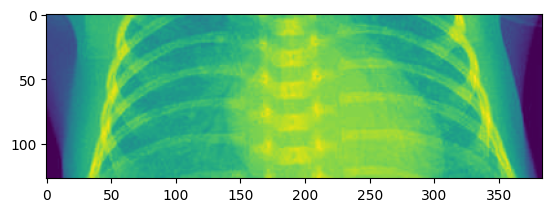

In [29]:
df.to_csv('hcml_projects/task_2/dataframes/originalIMG.csv')
test_df.to_csv('hcml_projects/task_2/dataframes/originalIMG_test.csv')
print(df['width'].idxmin())
print(df.iloc[df['width'].idxmin()]['url'])
img = cv2.imread(df['url'][df['width'].idxmin()], cv2.IMREAD_GRAYSCALE)
plt.imshow(img)
print(df['height'].min())

In [30]:
def resize_with_padding(img, target_size=224):
    h, w = img.shape[:2]
    scale = target_size / max(h, w)
    resized = cv2.resize(img, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_AREA)

    delta_w = target_size - resized.shape[1]
    delta_h = target_size - resized.shape[0]
    top, bottom = delta_h // 2, delta_h - (delta_h // 2)
    left, right = delta_w // 2, delta_w - (delta_w // 2)

    color = 0 
    padded = cv2.copyMakeBorder(resized, top, bottom, left, right, cv2.BORDER_CONSTANT, value=color)
    return padded

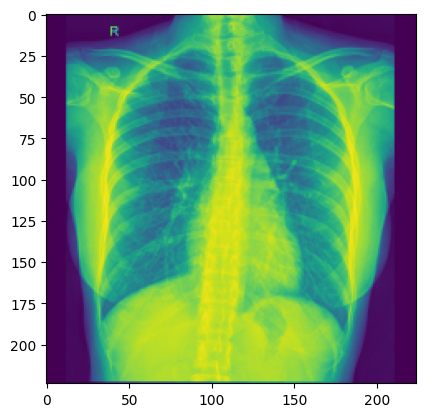

In [31]:
img = cv2.imread(df['url'][df['width'].idxmax()], cv2.IMREAD_GRAYSCALE)
# img = cv2.imread(df['url'][2], cv2.IMREAD_GRAYSCALE)
img = resize_with_padding(img)
plt.imshow(img)

In [32]:
df_train = pd.DataFrame(columns=['url', 'label', 'width', 'height'])
df_test = pd.DataFrame(columns=['url', 'label', 'width', 'height'])

for idx, img_row in df.iterrows():
    img = cv2.imread(img_row['url'], cv2.IMREAD_GRAYSCALE)
    img = resize_with_padding(img)

    cv2.imwrite('hcml_projects/task_2/preprocessed/train/' + str(idx) + '.jpg', img)
    df_train = pd.concat([df_train, pd.DataFrame([{'url': 'hcml_projects/task_2/preprocessed/train/' + str(idx) + '.jpg', 'label': img_row['label'], 'width': img.shape[0], 'height': img.shape[1]}])])

for idx, img_row in test_df.iterrows():
    img = cv2.imread(img_row['url'], cv2.IMREAD_GRAYSCALE)
    img = resize_with_padding(img)

    cv2.imwrite('hcml_projects/task_2/preprocessed/test/' + str(idx) + '.jpg', img)
    df_test = pd.concat([df_test, pd.DataFrame([{'url': 'hcml_projects/task_2/preprocessed/test/' + str(idx) + '.jpg', 'label': img_row['label'], 'width': img.shape[0], 'height': img.shape[1]}])])

df_train.to_csv('hcml_projects/task_2/dataframes/preprocessedIMG.csv')
df_test.to_csv('hcml_projects/task_2/dataframes/preprocessedIMG_test.csv')

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from PIL import Image
from io import BytesIO
import cv2

df_train = pd.read_csv('hcml_projects/task_2/dataframes/preprocessedIMG.csv')
df_train = df_train.drop(columns=['Unnamed: 0'])
df_train['output'] = df_train['label'].apply(lambda x: np.array([1, 0, 0]) if x == 'normal' else np.array([0, 1, 0]) if x == 'bacterial' else np.array([0, 0, 1]))

df_test = pd.read_csv('hcml_projects/task_2/dataframes/preprocessedIMG_test.csv')
df_test = df_test.drop(columns=['Unnamed: 0'])
df_test['output'] = df_test['label'].apply(lambda x: np.array([1, 0, 0]) if x == 'normal' else np.array([0, 1, 0]) if x == 'bacterial' else np.array([0, 0, 1]))
df_test


,url,label,width,height,output
0,hcml_projects/task_2/preprocessed/test/0.jpg,normal,224,224,"[1, 0, 0]"
1,hcml_projects/task_2/preprocessed/test/1.jpg,normal,224,224,"[1, 0, 0]"
2,hcml_projects/task_2/preprocessed/test/2.jpg,normal,224,224,"[1, 0, 0]"
3,hcml_projects/task_2/preprocessed/test/3.jpg,normal,224,224,"[1, 0, 0]"
4,hcml_projects/task_2/preprocessed/test/4.jpg,normal,224,224,"[1, 0, 0]"
...,...,...,...,...,...
5212,hcml_projects/task_2/preprocessed/test/5212.jpg,viral,224,224,"[0, 0, 1]"
5213,hcml_projects/task_2/preprocessed/test/5213.jpg,bacterial,224,224,"[0, 1, 0]"
5214,hcml_projects/task_2/preprocessed/test/5214.jpg,bacterial,224,224,"[0, 1, 0]"
5215,hcml_projects/task_2/preprocessed/test/5215.jpg,bacterial,224,224,"[0, 1, 0]"


<h2>Q2: CNN Classifier</h2>

In [2]:
def resize_with_padding(img, target_size=224):
    h, w = img.shape[:2]
    scale = target_size / max(h, w)
    resized = cv2.resize(img, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_AREA)

    delta_w = target_size - resized.shape[1]
    delta_h = target_size - resized.shape[0]
    top, bottom = delta_h // 2, delta_h - (delta_h // 2)
    left, right = delta_w // 2, delta_w - (delta_w // 2)

    color = 0 
    padded = cv2.copyMakeBorder(resized, top, bottom, left, right, cv2.BORDER_CONSTANT, value=color)
    return padded

In [3]:
class CNNClassifier(nn.Module):
    def __init__(self):
        super(CNNClassifier, self).__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, stride=1, padding=1)  # Reduced filters
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, stride=1, padding=1)  # Reduced filters
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(16 * 112 * 112, 64)  # Adjusted input size
        self.fc2 = nn.Linear(64, 3)  # 3 classes: Normal, Bacterial, Viral

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)  # Flatten the tensor
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [4]:
from torch.utils.data import Dataset, DataLoader

train_preprocess_url = 'hcml_projects/task_2/preprocessed/train/'
test_preprocess_url = 'hcml_projects/task_2/preprocessed/test/'

# Custom Dataset class
class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = resize_with_padding

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img = cv2.imread(row['url'], cv2.IMREAD_GRAYSCALE)
        label = np.array(row['output']).astype(float)  # Convert label to index
        if self.transform:
            img = self.transform(img)
        return img, label

In [ ]:
# Create dataset and dataloader
trainDataset = ChestXrayDataset(df_train)
trainDataloader = DataLoader(trainDataset, batch_size=32, shuffle=True)

# Initialize model, loss function, and optimizer
model = CNNClassifier()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 5
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    count = 0
    for images, labels in trainDataloader:
        count += 1
        images = images.unsqueeze(1).float()  # Add channel dimension
        labels = labels

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        # print(f"Batch: {count}/{len(trainDataloader)}, Batch Loss: {loss.item()}")

    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(trainDataloader)}")

Batch: 1/163, Batch Loss: 2.4658700608852087
Batch: 2/163, Batch Loss: 550.3171000480652
Batch: 3/163, Batch Loss: 739.8620185852051
Batch: 4/163, Batch Loss: 641.6131477471004
Batch: 5/163, Batch Loss: 299.0344181060791
Batch: 6/163, Batch Loss: 85.35642623901367
Batch: 7/163, Batch Loss: 184.62213230133057
Batch: 8/163, Batch Loss: 239.10900211334229
Batch: 9/163, Batch Loss: 113.76635426326328
Batch: 10/163, Batch Loss: 20.60234584039739
Batch: 11/163, Batch Loss: 28.366616361548083
Batch: 12/163, Batch Loss: 36.00325930491027
Batch: 13/163, Batch Loss: 19.03374730941033
Batch: 14/163, Batch Loss: 26.85675368201531
Batch: 15/163, Batch Loss: 8.780405702023444
Batch: 16/163, Batch Loss: 10.182481090110242
Batch: 17/163, Batch Loss: 1.6038172286363765
Batch: 18/163, Batch Loss: 6.599800214184995
Batch: 19/163, Batch Loss: 11.002678974763484
Batch: 20/163, Batch Loss: 3.774419776514897
Batch: 21/163, Batch Loss: 3.3503829579899493
Batch: 22/163, Batch Loss: 2.3959585807688164
Batch: 23

In [ ]:
torch.save(model.state_dict(), 'hcml_projects/task_2/chest_xray_cnn.pth')


In [5]:
model = CNNClassifier()
model.load_state_dict(torch.load('hcml_projects/task_2/chest_xray_cnn.pth'))


<All keys matched successfully>

Test Accuracy: 0.9744

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      1341
   Bacterial       0.99      0.94      0.96      2531
       Viral       0.89      0.97      0.93      1345

    accuracy                           0.96      5217
   macro avg       0.96      0.97      0.96      5217
weighted avg       0.96      0.96      0.96      5217



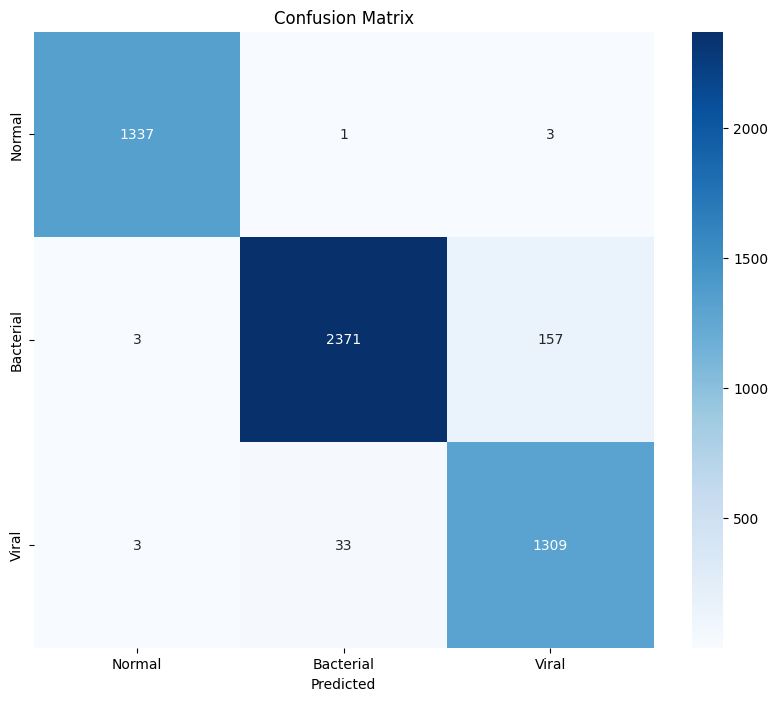

In [6]:
testDataset = ChestXrayDataset(df_test)
testDataloader = DataLoader(testDataset, batch_size=32, shuffle=False)

# Evaluation on test set
model.eval()  # Set model to evaluation mode
test_predictions = []
test_labels = []

with torch.no_grad():  # No need to track gradients during evaluation
    for images, labels in testDataloader:
        images = images.unsqueeze(1).float()  # Add channel dimension
        outputs = model(images)
        predicted = torch.argmax(outputs, dim=1).cpu().numpy()
        predicted_arr = np.array([np.array([1, 0, 0]) if x == 0 else np.array([0, 1, 0]) if x == 1 else np.array([0, 0, 1]) for x in predicted])
        test_predictions.extend(predicted_arr)
        test_labels.extend(labels.cpu().numpy())

# Convert predictions and labels to numpy arrays
test_predictions = np.array(test_predictions)
test_labels = np.array(test_labels)

# Calculate accuracy
accuracy = (test_predictions == test_labels).mean()
print(f"Test Accuracy: {accuracy:.4f}")

# Convert one-hot encoded labels to single-label encoded format
test_labels_single = np.argmax(test_labels, axis=1)
test_predictions_single = np.argmax(test_predictions, axis=1)

# Print classification report
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(test_labels_single, test_predictions_single, target_names=['Normal', 'Bacterial', 'Viral']))

# Calculate confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(test_labels_single, test_predictions_single)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Bacterial', 'Viral'],
            yticklabels=['Normal', 'Bacterial', 'Viral'])
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

<h2>Q3</h2>

In [7]:
from captum.attr import IntegratedGradients
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/tmp/ipykernel_17974/2171739330.py:6: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  inputs = torch.tensor([np.array(cv2.imread(row['url'], cv2.IMREAD_GRAYSCALE)).astype(np.float32) for _, row in images.iterrows()]).float()


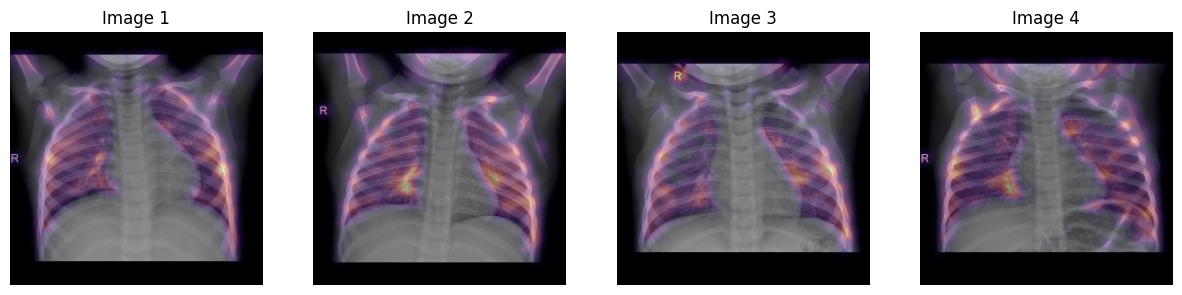

Random Baselines


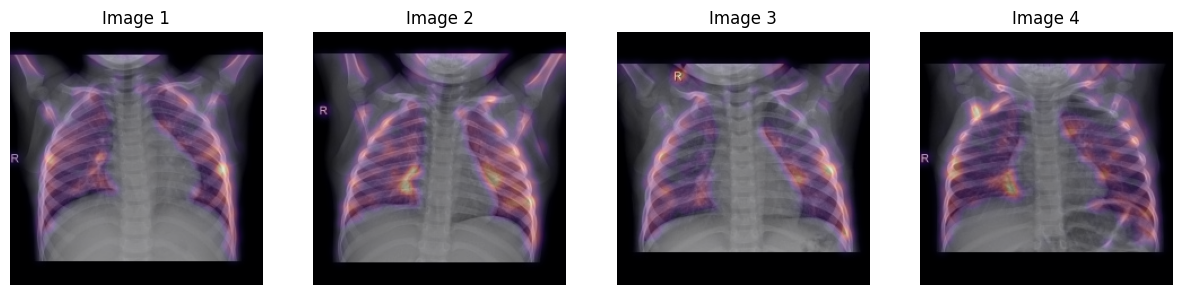

In [8]:
from scipy.ndimage import gaussian_filter

ig = IntegratedGradients(model)
images = df_test[df_test['label'] == 'normal'][:4]

inputs = torch.tensor([np.array(cv2.imread(row['url'], cv2.IMREAD_GRAYSCALE)).astype(np.float32) for _, row in images.iterrows()]).float()
inputs = inputs.unsqueeze(1)

class_idx = 0  
baselines = torch.zeros_like(inputs)  
random_baselines = torch.rand_like(inputs) 

attributions, delta = ig.attribute(inputs, baselines=baselines, target=class_idx, return_convergence_delta=True)

fig, axes = plt.subplots(1, len(images), figsize=(15, 5))
for i, ax in enumerate(axes):
    img = inputs[i].squeeze().numpy()
    attr = attributions[i].squeeze().numpy()
    attr = np.maximum(attr, 0)
    attr = gaussian_filter(attr, sigma=4)

    ax.imshow(img, cmap='gray')
    ax.imshow(attr, cmap='magma', alpha=0.4)
    ax.set_title(f"Image {i+1}")
    ax.axis('off')

plt.show()
print("Random Baselines")
attributions, delta = ig.attribute(inputs, baselines=random_baselines, target=class_idx, return_convergence_delta=True)

fig, axes = plt.subplots(1, len(images), figsize=(15, 5))
for i, ax in enumerate(axes):
    img = inputs[i].squeeze().numpy()
    attr = attributions[i].squeeze().numpy()
    attr = np.maximum(attr, 0)
    attr = gaussian_filter(attr, sigma=4)

    ax.imshow(img, cmap='gray')
    ax.imshow(attr, cmap='magma', alpha=0.4)
    ax.set_title(f"Image {i+1}")
    ax.axis('off')

plt.show()


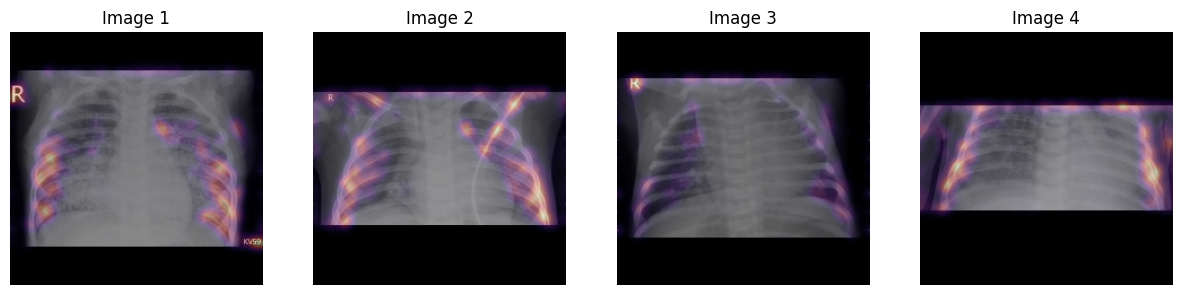

Random Baselines


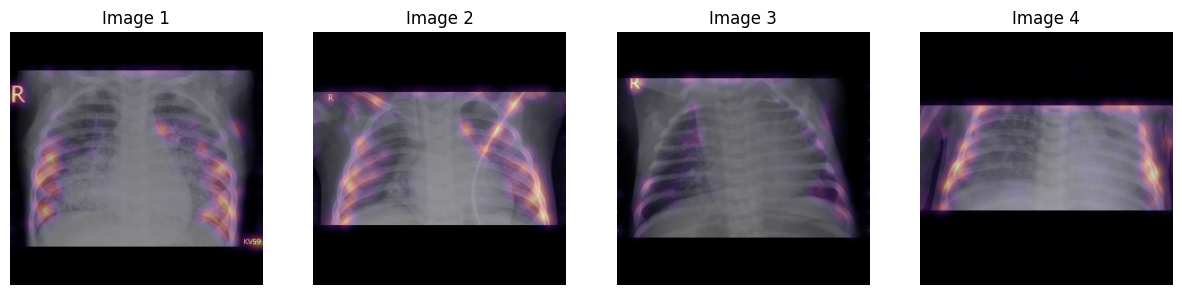

In [9]:
from scipy.ndimage import gaussian_filter

ig = IntegratedGradients(model)
images = df_test[df_test['label'] == 'bacterial'][:4]

inputs = torch.tensor([np.array(cv2.imread(row['url'], cv2.IMREAD_GRAYSCALE)).astype(np.float32) for _, row in images.iterrows()]).float()
inputs = inputs.unsqueeze(1)  

class_idx = 1
baselines = torch.zeros_like(inputs)  
random_baselines = torch.rand_like(inputs) 

attributions, delta = ig.attribute(inputs, baselines=baselines, target=class_idx, return_convergence_delta=True)

fig, axes = plt.subplots(1, len(images), figsize=(15, 5))
for i, ax in enumerate(axes):
    img = inputs[i].squeeze().numpy()
    attr = attributions[i].squeeze().numpy()
    attr = np.maximum(attr, 0)
    attr = gaussian_filter(attr, sigma=4)

    ax.imshow(img, cmap='gray')
    ax.imshow(attr, cmap='magma', alpha=0.4)
    ax.set_title(f"Image {i+1}")
    ax.axis('off')

plt.show()

print("Random Baselines")
attributions, delta = ig.attribute(inputs, baselines=random_baselines, target=class_idx, return_convergence_delta=True)

fig, axes = plt.subplots(1, len(images), figsize=(15, 5))
for i, ax in enumerate(axes):
    img = inputs[i].squeeze().numpy()
    attr = attributions[i].squeeze().numpy()
    attr = np.maximum(attr, 0)
    attr = gaussian_filter(attr, sigma=4)

    ax.imshow(img, cmap='gray')
    ax.imshow(attr, cmap='magma', alpha=0.4)
    ax.set_title(f"Image {i+1}")
    ax.axis('off')

plt.show()

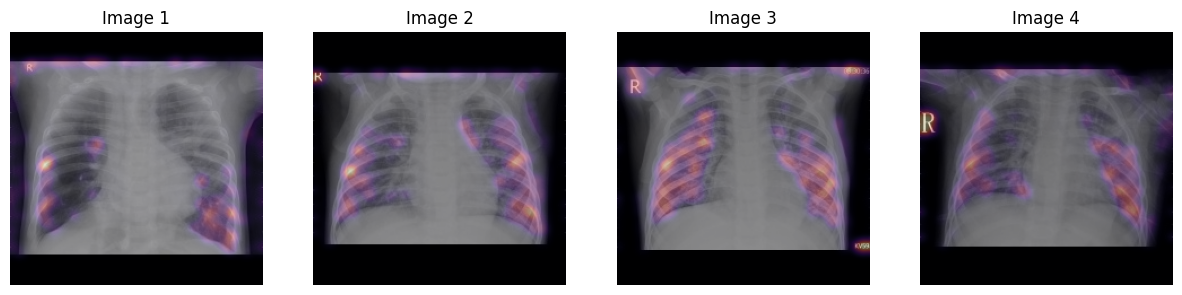

Random Baselines


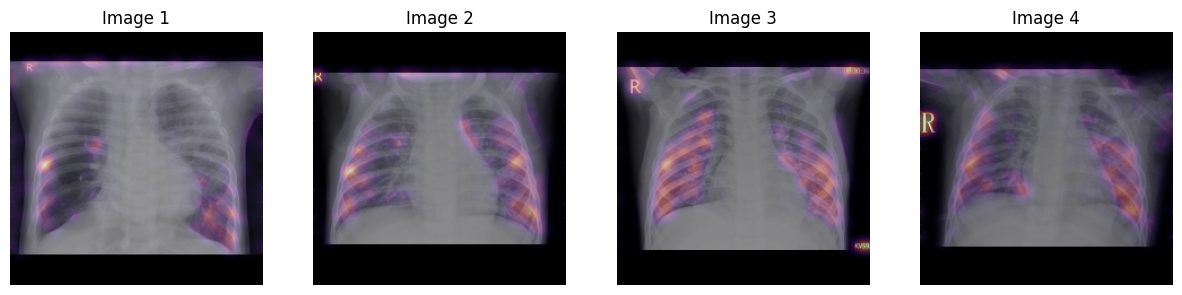

In [10]:
from scipy.ndimage import gaussian_filter

ig = IntegratedGradients(model)
images = df_test[df_test['label'] == 'viral'][:4]

inputs = torch.tensor([np.array(cv2.imread(row['url'], cv2.IMREAD_GRAYSCALE)).astype(np.float32) for _, row in images.iterrows()]).float()
inputs = inputs.unsqueeze(1)  

class_idx = 2  
baselines = torch.zeros_like(inputs)  
random_baselines = torch.rand_like(inputs) 

attributions, delta = ig.attribute(inputs, baselines=baselines, target=class_idx, return_convergence_delta=True)

fig, axes = plt.subplots(1, len(images), figsize=(15, 5))
for i, ax in enumerate(axes):
    img = inputs[i].squeeze().numpy()
    attr = attributions[i].squeeze().numpy()
    attr = np.maximum(attr, 0)
    attr = gaussian_filter(attr, sigma=4)

    ax.imshow(img, cmap='gray')
    ax.imshow(attr, cmap='magma', alpha=0.4)
    ax.set_title(f"Image {i+1}")
    ax.axis('off')

plt.show()
print("Random Baselines")
attributions, delta = ig.attribute(inputs, baselines=random_baselines, target=class_idx, return_convergence_delta=True)

fig, axes = plt.subplots(1, len(images), figsize=(15, 5))
for i, ax in enumerate(axes):
    img = inputs[i].squeeze().numpy()
    attr = attributions[i].squeeze().numpy()
    attr = np.maximum(attr, 0)
    attr = gaussian_filter(attr, sigma=4)

    ax.imshow(img, cmap='gray')
    ax.imshow(attr, cmap='magma', alpha=0.4)
    ax.set_title(f"Image {i+1}")
    ax.axis('off')

plt.show()

/tmp/ipykernel_37977/3279904517.py:14: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  inputs = torch.tensor([


torch.Size([4, 1, 224, 224])


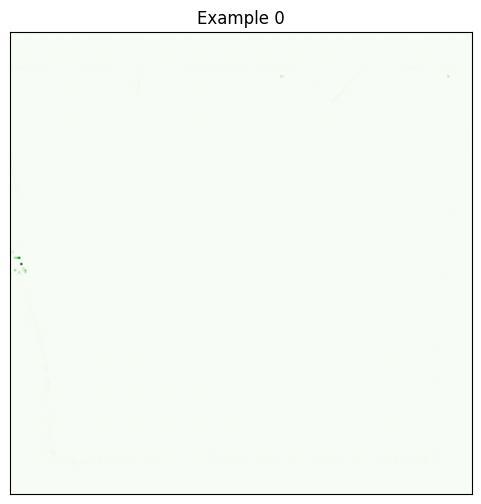

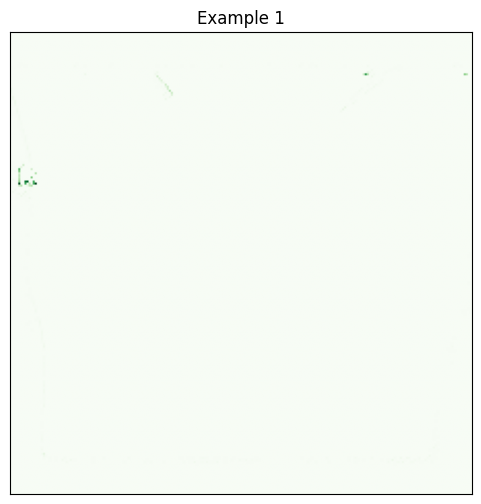

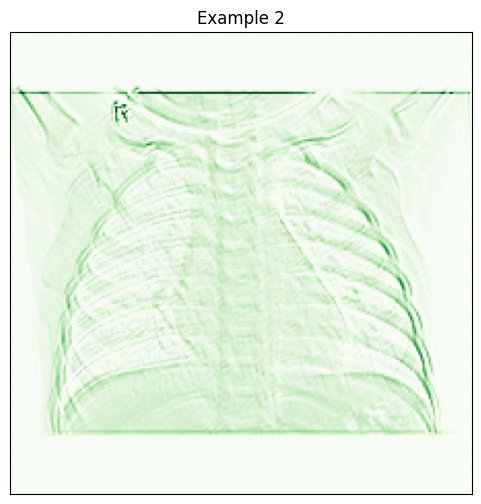

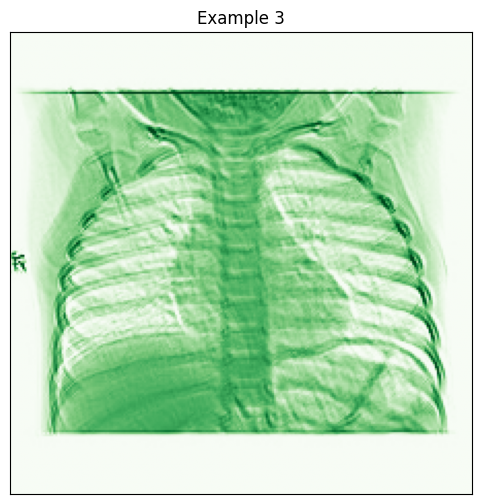

In [6]:
from captum.attr import LayerGradCam, LayerAttribution
from captum.attr import visualization as viz

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNClassifier()
model.load_state_dict(torch.load('hcml_projects/task_2/chest_xray_cnn.pth'))
model.to(device)

target_layer = model.conv2
layer_gradcam = LayerGradCam(model, target_layer)

images = df_test[df_test['label'] == 'normal'][:4]

inputs = torch.tensor([
    cv2.resize(cv2.imread(row['url'], cv2.IMREAD_GRAYSCALE), (224, 224)).astype(np.float32)
    for _, row in images.iterrows()
]).float()

inputs = inputs.unsqueeze(1)  

print(inputs.shape)

class_idx = 0

attributions_lgc = layer_gradcam.attribute(inputs.to(device), target=class_idx)

attributions_lgc = LayerAttribution.interpolate(attributions_lgc, inputs.shape[2:])

_ = viz.visualize_image_attr(attributions_lgc[0].cpu().permute(1,2,0).detach().numpy(),
                             sign="positive",
                             title="Example 0",)
_ = viz.visualize_image_attr(attributions_lgc[1].cpu().permute(1,2,0).detach().numpy(),
                                sign="positive",
                                title="Example 1",)
_ = viz.visualize_image_attr(attributions_lgc[2].cpu().permute(1,2,0).detach().numpy(),
                                sign="positive",
                                title="Example 2",)
_ = viz.visualize_image_attr(attributions_lgc[3].cpu().permute(1,2,0).detach().numpy(),
                                sign="positive",
                                title="Example 3",)

torch.Size([4, 1, 224, 224])


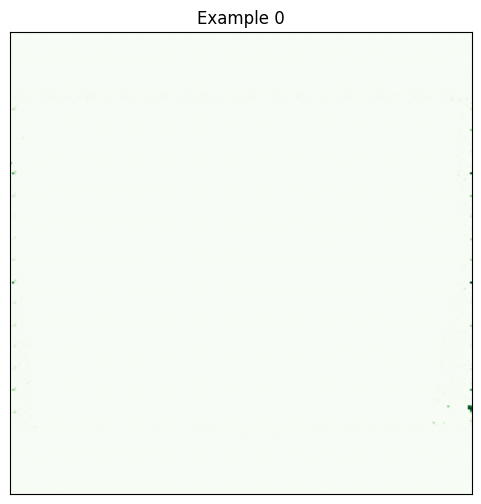

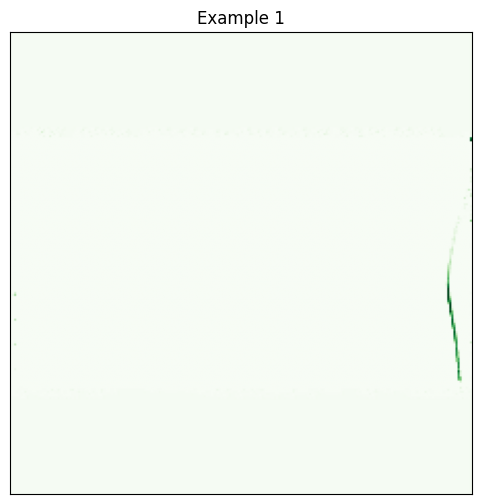

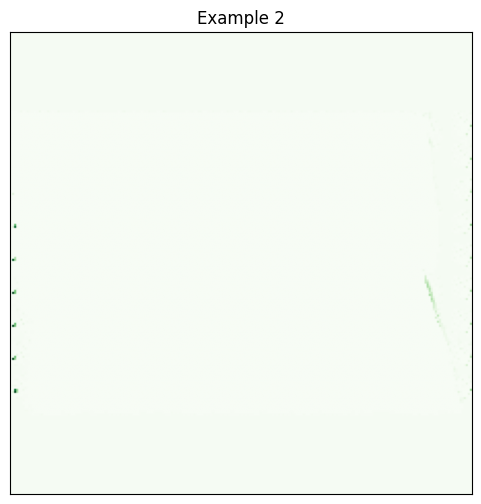

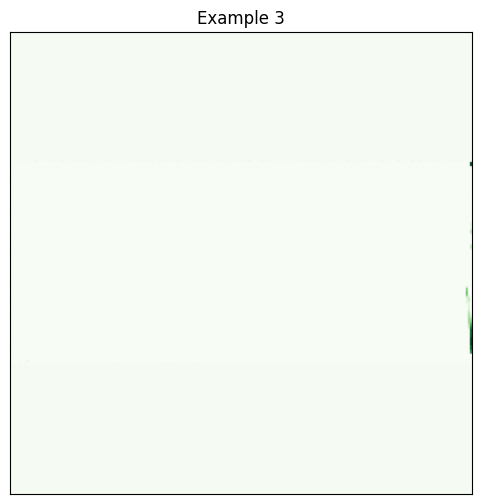

In [7]:
images = df_test[df_test['label'] == 'bacterial'][:4]

inputs = torch.tensor([
    cv2.resize(cv2.imread(row['url'], cv2.IMREAD_GRAYSCALE), (224, 224)).astype(np.float32)
    for _, row in images.iterrows()
]).float()

inputs = inputs.unsqueeze(1)  

print(inputs.shape)

class_idx = 1

attributions_lgc = layer_gradcam.attribute(inputs.to(device), target=class_idx)

attributions_lgc = LayerAttribution.interpolate(attributions_lgc, inputs.shape[2:])


_ = viz.visualize_image_attr(attributions_lgc[0].cpu().permute(1,2,0).detach().numpy(),
                             sign="positive",
                             title="Example 0",)
_ = viz.visualize_image_attr(attributions_lgc[1].cpu().permute(1,2,0).detach().numpy(),
                                sign="positive",
                                title="Example 1",)
_ = viz.visualize_image_attr(attributions_lgc[2].cpu().permute(1,2,0).detach().numpy(),
                                sign="positive",
                                title="Example 2",)
_ = viz.visualize_image_attr(attributions_lgc[3].cpu().permute(1,2,0).detach().numpy(),
                                sign="positive",
                                title="Example 3",)

torch.Size([4, 1, 224, 224])


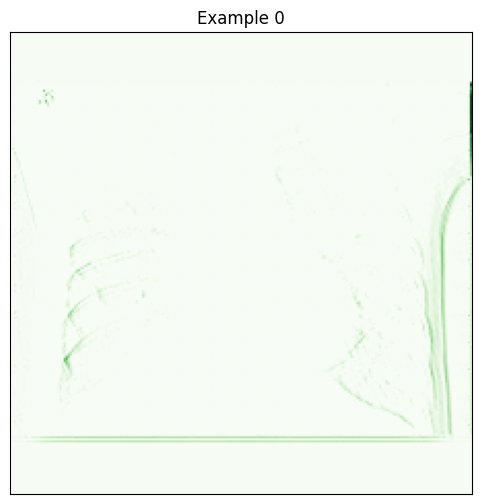

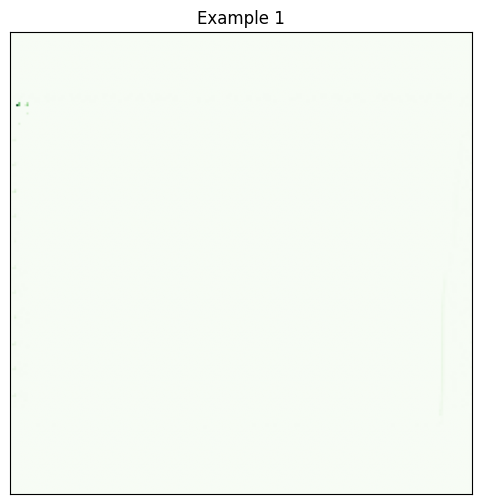

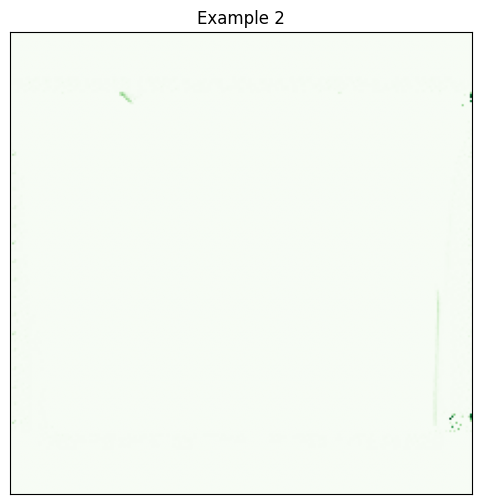

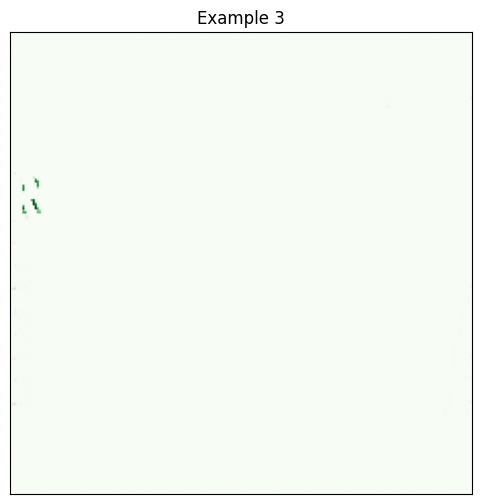

In [8]:
images = df_test[df_test['label'] == 'viral'][:4]

inputs = torch.tensor([
    cv2.resize(cv2.imread(row['url'], cv2.IMREAD_GRAYSCALE), (224, 224)).astype(np.float32)
    for _, row in images.iterrows()
]).float()

inputs = inputs.unsqueeze(1)  

print(inputs.shape)

class_idx = 2

attributions_lgc = layer_gradcam.attribute(inputs.to(device), target=class_idx)

attributions_lgc = LayerAttribution.interpolate(attributions_lgc, inputs.shape[2:])


_ = viz.visualize_image_attr(attributions_lgc[0].cpu().permute(1,2,0).detach().numpy(),
                             sign="positive",
                             title="Example 0",)
_ = viz.visualize_image_attr(attributions_lgc[1].cpu().permute(1,2,0).detach().numpy(),
                                sign="positive",
                                title="Example 1",)
_ = viz.visualize_image_attr(attributions_lgc[2].cpu().permute(1,2,0).detach().numpy(),
                                sign="positive",
                                title="Example 2",)
_ = viz.visualize_image_attr(attributions_lgc[3].cpu().permute(1,2,0).detach().numpy(),
                                sign="positive",
                                title="Example 3",)

<h2>Q5</h2>

In [29]:
randomized_df_train = df_train.copy()
randomized_df_train['output'] = randomized_df_train['output'].sample(frac=1).reset_index(drop=True)

randomized_trainDataset = ChestXrayDataset(randomized_df_train)
randomized_trainDataloader = DataLoader(randomized_trainDataset, batch_size=32, shuffle=False)

randomized_model = CNNClassifier()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(randomized_model.parameters(), lr=0.001)

# Training loop
epochs = 5
for epoch in range(epochs):
    randomized_model.train()
    running_loss = 0.0
    count = 0
    for images, labels in randomized_trainDataloader:
        count += 1
        images = images.unsqueeze(1).float()  # Add channel dimension
        labels = labels

        optimizer.zero_grad()
        outputs = randomized_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(randomized_trainDataloader)}")

torch.save(randomized_model.state_dict(), 'hcml_projects/task_2/chest_xray_cnn_randomized.pth')


Epoch 1/5, Loss: 31.750795817941064
Epoch 2/5, Loss: 1.021277606504058
Epoch 3/5, Loss: 0.8991596586858767
Epoch 4/5, Loss: 0.734195627556078
Epoch 5/5, Loss: 0.5747200170871608


In [9]:
randomized_model = CNNClassifier()
randomized_model.load_state_dict(torch.load('hcml_projects/task_2/chest_xray_cnn_randomized.pth'))

<All keys matched successfully>

Randomized Model Integrated Gradients


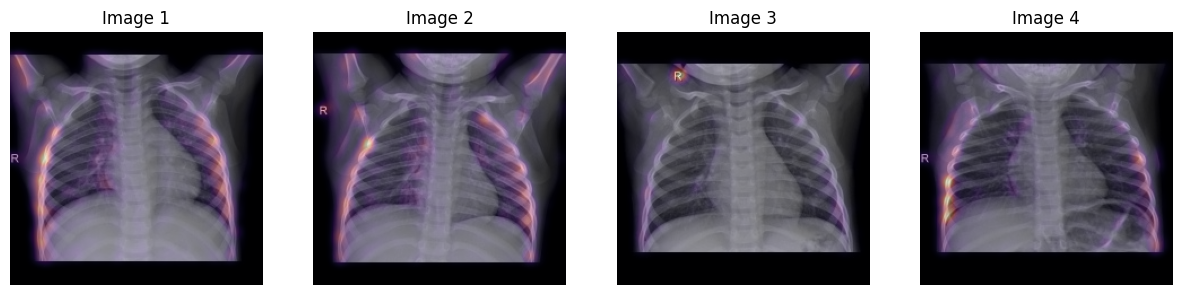

In [31]:
print("Randomized Model Integrated Gradients")
from captum.attr import IntegratedGradients
from scipy.ndimage import gaussian_filter

ig = IntegratedGradients(randomized_model)
images = df_test[df_test['label'] == 'normal'][:4]

inputs = torch.tensor([np.array(cv2.imread(row['url'], cv2.IMREAD_GRAYSCALE)).astype(np.float32) for _, row in images.iterrows()]).float()
inputs = inputs.unsqueeze(1)

class_idx = 0  
baselines = torch.zeros_like(inputs)  
random_baselines = torch.rand_like(inputs) 

attributions, delta = ig.attribute(inputs, baselines=baselines, target=class_idx, return_convergence_delta=True)

fig, axes = plt.subplots(1, len(images), figsize=(15, 5))
for i, ax in enumerate(axes):
    img = inputs[i].squeeze().numpy()
    attr = attributions[i].squeeze().numpy()
    attr = np.maximum(attr, 0)
    attr = gaussian_filter(attr, sigma=4)

    ax.imshow(img, cmap='gray')
    ax.imshow(attr, cmap='magma', alpha=0.4)
    ax.set_title(f"Image {i+1}")
    ax.axis('off')

plt.show()

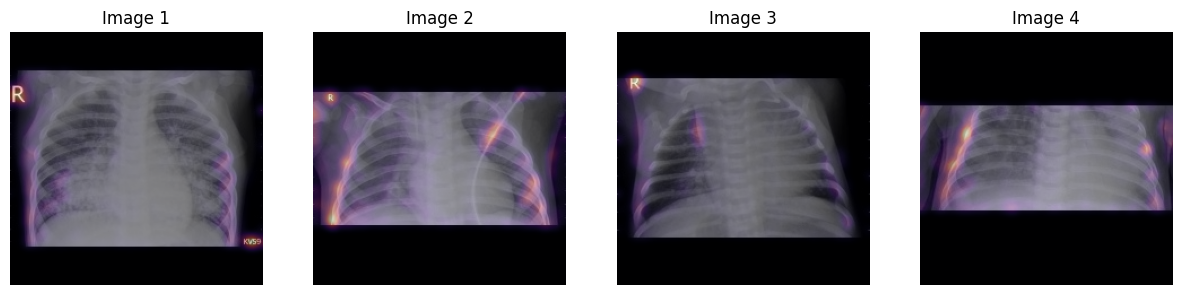

In [32]:
from captum.attr import IntegratedGradients
from scipy.ndimage import gaussian_filter

ig = IntegratedGradients(randomized_model)
images = df_test[df_test['label'] == 'bacterial'][:4]

inputs = torch.tensor([np.array(cv2.imread(row['url'], cv2.IMREAD_GRAYSCALE)).astype(np.float32) for _, row in images.iterrows()]).float()
inputs = inputs.unsqueeze(1)

class_idx = 1
baselines = torch.zeros_like(inputs)  
random_baselines = torch.rand_like(inputs) 

attributions, delta = ig.attribute(inputs, baselines=baselines, target=class_idx, return_convergence_delta=True)

fig, axes = plt.subplots(1, len(images), figsize=(15, 5))
for i, ax in enumerate(axes):
    img = inputs[i].squeeze().numpy()
    attr = attributions[i].squeeze().numpy()
    attr = np.maximum(attr, 0)
    attr = gaussian_filter(attr, sigma=4)

    ax.imshow(img, cmap='gray')
    ax.imshow(attr, cmap='magma', alpha=0.4)
    ax.set_title(f"Image {i+1}")
    ax.axis('off')

plt.show()

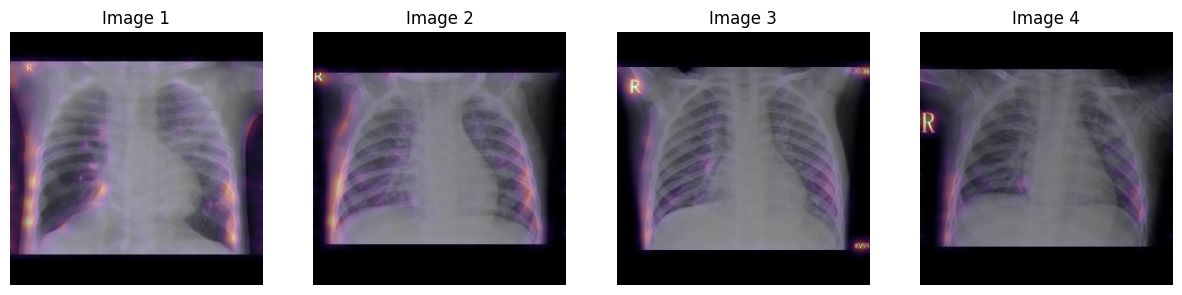

In [33]:
from captum.attr import IntegratedGradients
from scipy.ndimage import gaussian_filter

ig = IntegratedGradients(randomized_model)
images = df_test[df_test['label'] == 'viral'][:4]

inputs = torch.tensor([np.array(cv2.imread(row['url'], cv2.IMREAD_GRAYSCALE)).astype(np.float32) for _, row in images.iterrows()]).float()
inputs = inputs.unsqueeze(1)

class_idx = 2
baselines = torch.zeros_like(inputs)  
random_baselines = torch.rand_like(inputs) 

attributions, delta = ig.attribute(inputs, baselines=baselines, target=class_idx, return_convergence_delta=True)

fig, axes = plt.subplots(1, len(images), figsize=(15, 5))
for i, ax in enumerate(axes):
    img = inputs[i].squeeze().numpy()
    attr = attributions[i].squeeze().numpy()
    attr = np.maximum(attr, 0)
    attr = gaussian_filter(attr, sigma=4)

    ax.imshow(img, cmap='gray')
    ax.imshow(attr, cmap='magma', alpha=0.4)
    ax.set_title(f"Image {i+1}")
    ax.axis('off')

plt.show()

torch.Size([4, 1, 224, 224])


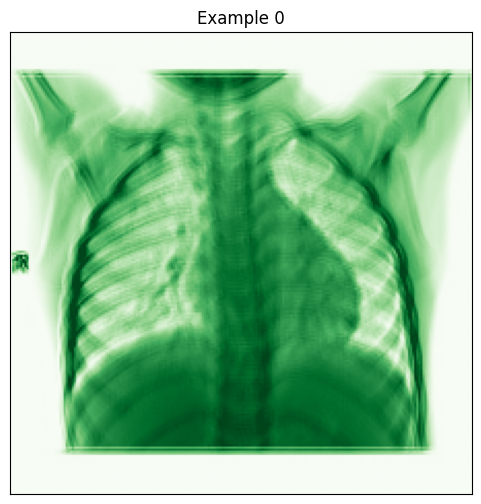

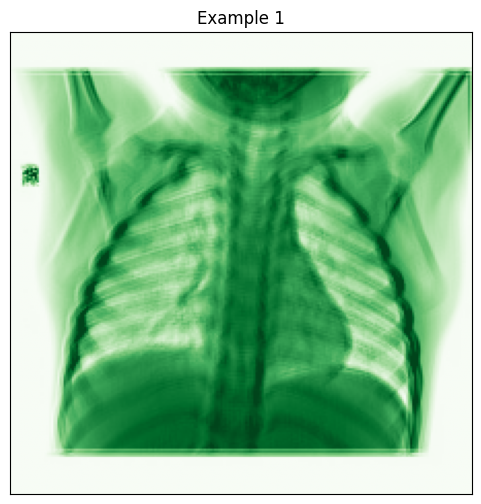

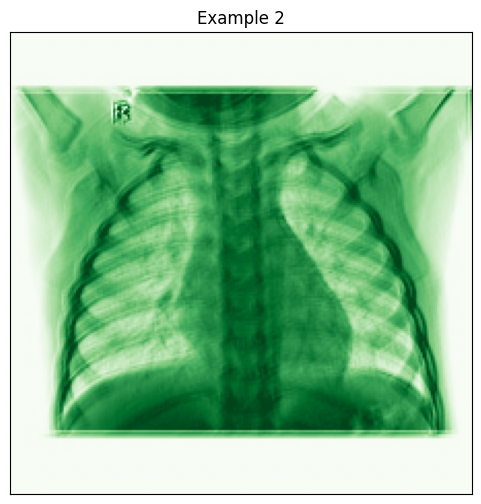

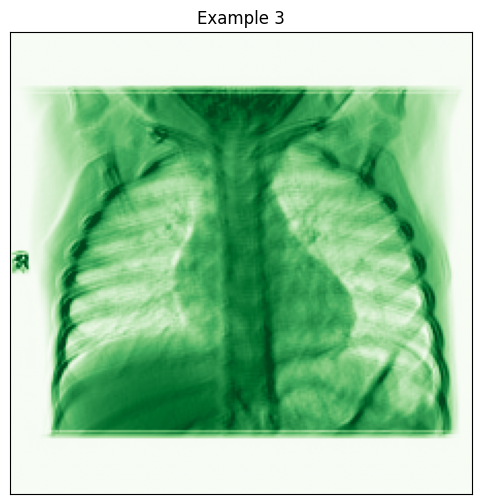

In [11]:
from captum.attr import LayerGradCam, LayerAttribution
from captum.attr import visualization as viz

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
randomized_model = CNNClassifier()
randomized_model.load_state_dict(torch.load('hcml_projects/task_2/chest_xray_cnn_randomized.pth'))
randomized_model.to(device)

target_layer = randomized_model.conv2
layer_gradcam = LayerGradCam(randomized_model, target_layer)

images = df_test[df_test['label'] == 'normal'][:4]

inputs = torch.tensor([
    cv2.resize(cv2.imread(row['url'], cv2.IMREAD_GRAYSCALE), (224, 224)).astype(np.float32)
    for _, row in images.iterrows()
]).float()

inputs = inputs.unsqueeze(1)  

print(inputs.shape)

class_idx = 0

attributions_lgc = layer_gradcam.attribute(inputs.to(device), target=class_idx)

attributions_lgc = LayerAttribution.interpolate(attributions_lgc, inputs.shape[2:])

_ = viz.visualize_image_attr(attributions_lgc[0].cpu().permute(1,2,0).detach().numpy(),
                             sign="positive",
                             title="Example 0",)
_ = viz.visualize_image_attr(attributions_lgc[1].cpu().permute(1,2,0).detach().numpy(),
                                sign="positive",
                                title="Example 1",)
_ = viz.visualize_image_attr(attributions_lgc[2].cpu().permute(1,2,0).detach().numpy(),
                                sign="positive",
                                title="Example 2",)
_ = viz.visualize_image_attr(attributions_lgc[3].cpu().permute(1,2,0).detach().numpy(),
                                sign="positive",
                                title="Example 3",)

torch.Size([4, 1, 224, 224])


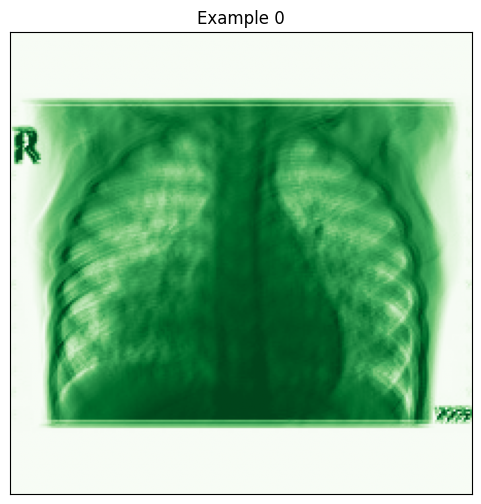

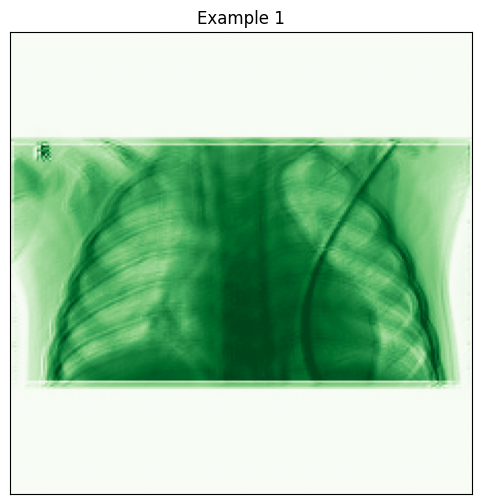

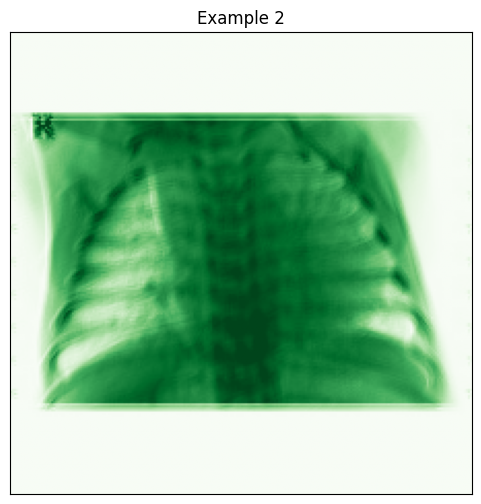

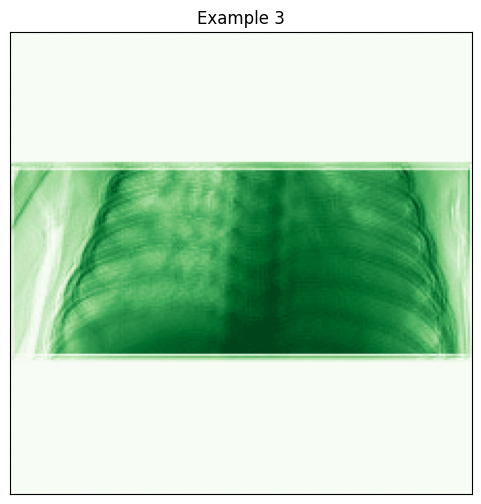

In [12]:
images = df_test[df_test['label'] == 'bacterial'][:4]

inputs = torch.tensor([
    cv2.resize(cv2.imread(row['url'], cv2.IMREAD_GRAYSCALE), (224, 224)).astype(np.float32)
    for _, row in images.iterrows()
]).float()

inputs = inputs.unsqueeze(1)  

print(inputs.shape)

class_idx = 1

attributions_lgc = layer_gradcam.attribute(inputs.to(device), target=class_idx)

attributions_lgc = LayerAttribution.interpolate(attributions_lgc, inputs.shape[2:])


_ = viz.visualize_image_attr(attributions_lgc[0].cpu().permute(1,2,0).detach().numpy(),
                             sign="positive",
                             title="Example 0",)
_ = viz.visualize_image_attr(attributions_lgc[1].cpu().permute(1,2,0).detach().numpy(),
                                sign="positive",
                                title="Example 1",)
_ = viz.visualize_image_attr(attributions_lgc[2].cpu().permute(1,2,0).detach().numpy(),
                                sign="positive",
                                title="Example 2",)
_ = viz.visualize_image_attr(attributions_lgc[3].cpu().permute(1,2,0).detach().numpy(),
                                sign="positive",
                                title="Example 3",)

torch.Size([4, 1, 224, 224])


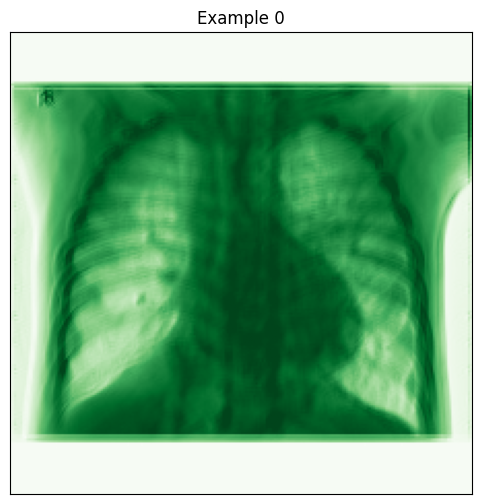

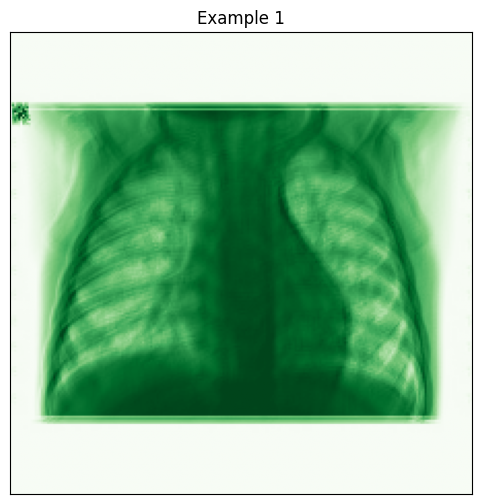

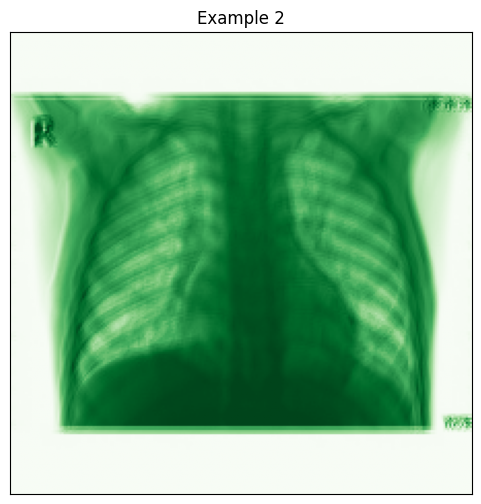

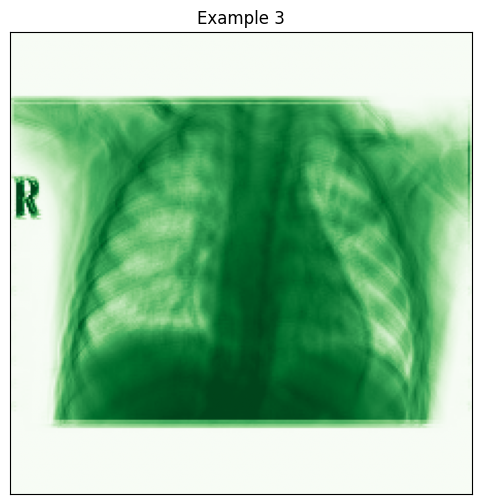

In [13]:
images = df_test[df_test['label'] == 'viral'][:4]

inputs = torch.tensor([
    cv2.resize(cv2.imread(row['url'], cv2.IMREAD_GRAYSCALE), (224, 224)).astype(np.float32)
    for _, row in images.iterrows()
]).float()

inputs = inputs.unsqueeze(1)  

print(inputs.shape)

class_idx = 2

attributions_lgc = layer_gradcam.attribute(inputs.to(device), target=class_idx)

attributions_lgc = LayerAttribution.interpolate(attributions_lgc, inputs.shape[2:])


_ = viz.visualize_image_attr(attributions_lgc[0].cpu().permute(1,2,0).detach().numpy(),
                             sign="positive",
                             title="Example 0",)
_ = viz.visualize_image_attr(attributions_lgc[1].cpu().permute(1,2,0).detach().numpy(),
                                sign="positive",
                                title="Example 1",)
_ = viz.visualize_image_attr(attributions_lgc[2].cpu().permute(1,2,0).detach().numpy(),
                                sign="positive",
                                title="Example 2",)
_ = viz.visualize_image_attr(attributions_lgc[3].cpu().permute(1,2,0).detach().numpy(),
                                sign="positive",
                                title="Example 3",)